In [3]:
# =========================================================
# LOAD INTERFACE DENSITY SHEET
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# File path
file_path = "Data_file.xlsx"

# Sheet name
sheet_name = "Interface density"

# Load dataset
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Display info
print("Interface Density Sheet Loaded Successfully!")
print("Shape of Dataset:", df.shape)

print("\nColumns in Interface Density Sheet:")
print(df.columns.tolist())

df.head()

Interface Density Sheet Loaded Successfully!
Shape of Dataset: (61, 47)

Columns in Interface Density Sheet:
['Jsc', 'v(V)', '10^10', '10^12', '10^14', '10^16', '10^18', '10^20', 'Unnamed: 8', 'Unnamed: 9', 'Interface Density', 'Jsc(mA/cm^2', 'Unnamed: 12', 'Unnamed: 13', 'Q.E.(%)', 'lambda(nm)', '10^10.1', '10^12.1', '10^14.1', '10^16.1', '10^18.1', '10^20.1', 'Unnamed: 22', 'Unnamed: 23', 'R(A/W)', 'lambda(nm).1', '10^10.2', '10^12.2', '10^14.2', '10^16.2', '10^18.2', '10^20.2', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Jsc.1', 'v(V).1', '10^10.3', '10^12.3', '10^14.3', '10^16.3', '10^18.3', '10^20.3', 'Unnamed: 43', 'Unnamed: 44', 'Defect Density', 'Jsc(mA/cm^2.1']


,Jsc,v(V),10^10,10^12,10^14,10^16,10^18,10^20,Unnamed: 8,Unnamed: 9,...,10^10.3,10^12.3,10^14.3,10^16.3,10^18.3,10^20.3,Unnamed: 43,Unnamed: 44,Defect Density,Jsc(mA/cm^2.1
0,NaN,0.00,23.596467,23.596187,23.568287,21.203038,9.036408,8.623125,NaN,NaN,...,22.700415,22.464333,22.461579,22.461518,22.459527,22.456576,NaN,NaN,10^10,22.700415
1,Sns2/PS,0.05,23.596325,23.596030,23.566606,21.092885,8.984168,8.589798,NaN,NaN,...,22.700343,22.464298,22.461545,22.461484,22.459458,22.456458,NaN,NaN,10^12,22.464333
2,NaN,0.10,23.596179,23.595866,23.564728,20.971003,8.928108,8.552836,NaN,NaN,...,22.700268,22.464260,22.461507,22.461445,22.459383,22.456332,NaN,NaN,10^14,22.461579
3,NaN,0.15,23.596028,23.595696,23.562614,20.835348,8.867563,8.511587,NaN,NaN,...,22.700189,22.464218,22.461466,22.461403,22.459301,22.456194,NaN,NaN,10^16,22.461518
4,NaN,0.20,23.595871,23.595518,23.560211,20.683363,8.801697,8.465229,NaN,NaN,...,22.700105,22.464172,22.461420,22.461357,22.459211,22.456044,NaN,NaN,10^18,22.459527


In [6]:
# =========================================================
# EXTRACT J-V DATA (INTERFACE DENSITY)
# =========================================================

# Select voltage + J-V columns only
jv_cols = ['v(V)'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.1' not in str(col) and '.2' not in str(col)
]

# Create J-V dataframe
jv_df = df[jv_cols]

# Convert wide to long format
jv_long = jv_df.melt(
    id_vars='v(V)',
    var_name='Interface_Density',
    value_name='Current'
)

# Extract exponent only (10^10 → 10)
jv_long['Interface_Density'] = jv_long['Interface_Density'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
jv_long.dropna(inplace=True)

# Rename columns
jv_long.rename(columns={'v(V)': 'Voltage'}, inplace=True)

# Reset index
jv_long.reset_index(drop=True, inplace=True)

print("J-V Interface Density Data Ready!")
print("Shape:", jv_long.shape)

jv_long.head()

J-V Interface Density Data Ready!
Shape: (246, 3)


,Voltage,Interface_Density,Current
0,0.00,10.0,23.596467
1,0.05,10.0,23.596325
2,0.10,10.0,23.596179
3,0.15,10.0,23.596028
4,0.20,10.0,23.595871


In [7]:
# =========================================================
# EXTRACT QE DATA (INTERFACE DENSITY)
# =========================================================

# Select wavelength + QE columns only
qe_cols = ['lambda(nm)'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.1' in str(col)
]

# Create QE dataframe
qe_df = df[qe_cols]

# Convert wide to long format
qe_long = qe_df.melt(
    id_vars='lambda(nm)',
    var_name='Interface_Density',
    value_name='QE'
)

# Extract exponent only (10^10.1 → 10)
qe_long['Interface_Density'] = qe_long['Interface_Density'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
qe_long.dropna(inplace=True)

# Rename columns
qe_long.rename(columns={'lambda(nm)': 'Wavelength'}, inplace=True)

# Reset index
qe_long.reset_index(drop=True, inplace=True)

print("QE Interface Density Data Ready!")
print("Shape:", qe_long.shape)

qe_long.head()

QE Interface Density Data Ready!
Shape: (366, 3)


,Wavelength,Interface_Density,QE
0,300,10.0,84.20149
1,310,10.0,85.19467
2,320,10.0,86.22041
3,330,10.0,87.29207
4,340,10.0,88.42869


In [8]:
# =========================================================
# EXTRACT RESPONSIVITY DATA (INTERFACE DENSITY)
# =========================================================

# Select wavelength + Responsivity columns only
r_cols = ['lambda(nm).1'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.2' in str(col)
]

# Create Responsivity dataframe
r_df = df[r_cols]

# Convert wide to long format
r_long = r_df.melt(
    id_vars='lambda(nm).1',
    var_name='Interface_Density',
    value_name='Responsivity'
)

# Extract exponent only (10^10.2 → 10)
r_long['Interface_Density'] = r_long['Interface_Density'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
r_long.dropna(inplace=True)

# Rename columns
r_long.rename(columns={'lambda(nm).1': 'Wavelength'}, inplace=True)

# Reset index
r_long.reset_index(drop=True, inplace=True)

print("Responsivity Interface Density Data Ready!")
print("Shape:", r_long.shape)

r_long.head()

Responsivity Interface Density Data Ready!
Shape: (366, 3)


,Wavelength,Interface_Density,Responsivity
0,300,10.0,0.203713
1,310,10.0,0.212987
2,320,10.0,0.222504
3,330,10.0,0.232310
4,340,10.0,0.242466


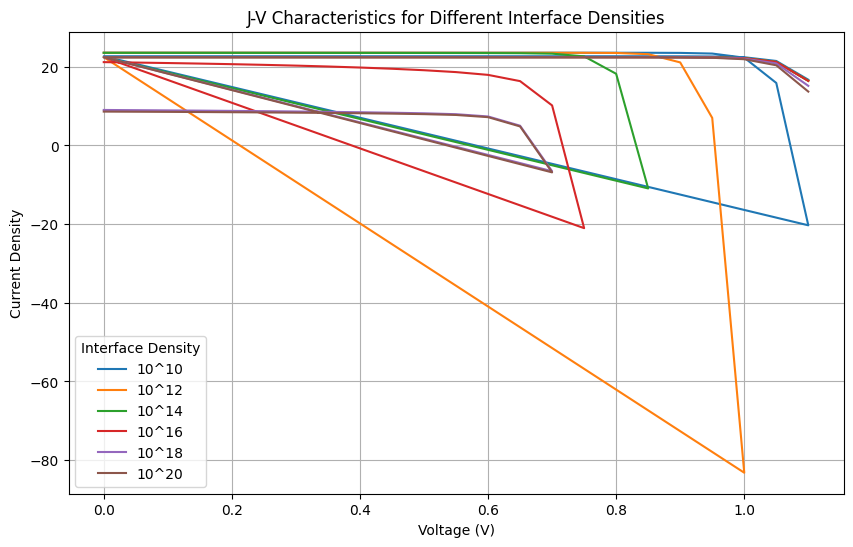

In [9]:
# =========================================================
# PLOT J-V CURVES (INTERFACE DENSITY)
# =========================================================

plt.figure(figsize=(10,6))

for density in sorted(jv_long['Interface_Density'].unique()):
    subset = jv_long[jv_long['Interface_Density'] == density]

    plt.plot(
        subset['Voltage'],
        subset['Current'],
        label=f'10^{int(density)}'
    )

plt.title("J-V Characteristics for Different Interface Densities")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density")

plt.legend(title="Interface Density")
plt.grid(True)
plt.show()

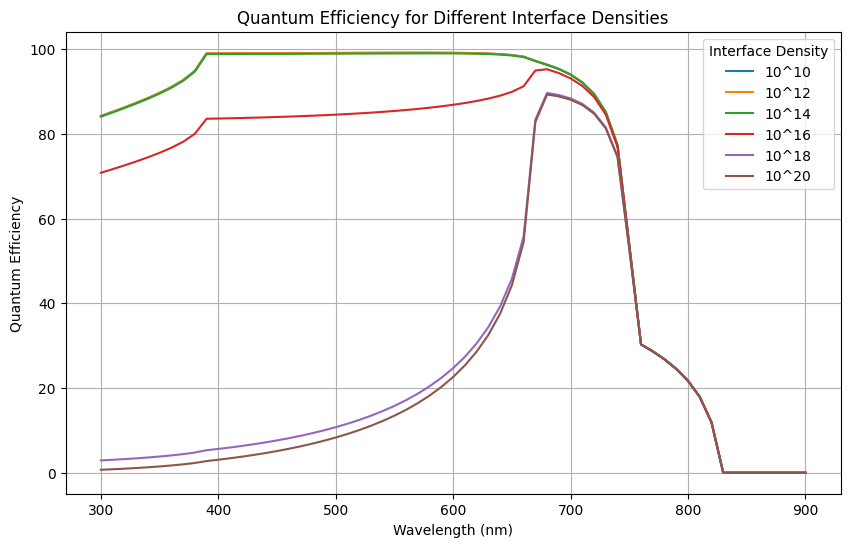

In [10]:
# =========================================================
# PLOT QE CURVES (INTERFACE DENSITY)
# =========================================================

plt.figure(figsize=(10,6))

for density in sorted(qe_long['Interface_Density'].unique()):
    subset = qe_long[qe_long['Interface_Density'] == density]

    plt.plot(
        subset['Wavelength'],
        subset['QE'],
        label=f'10^{int(density)}'
    )

plt.title("Quantum Efficiency for Different Interface Densities")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency")

plt.legend(title="Interface Density")
plt.grid(True)
plt.show()

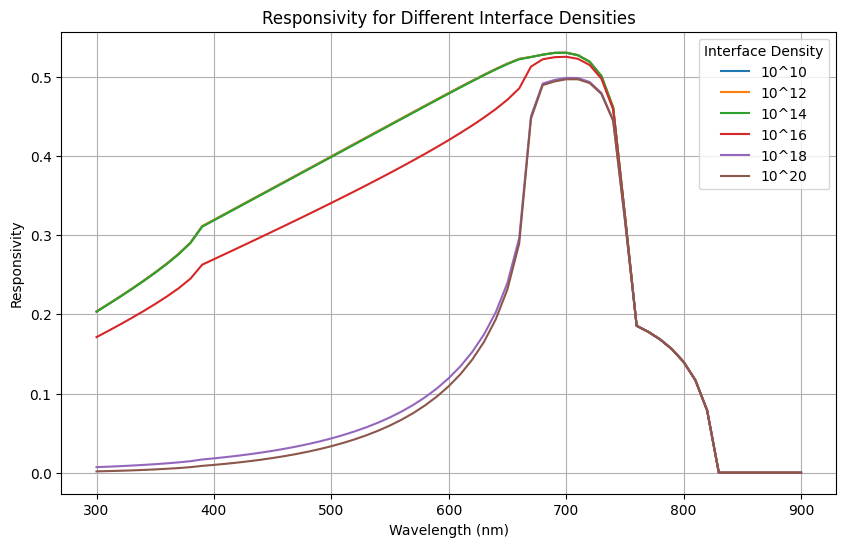

In [11]:
# =========================================================
# PLOT RESPONSIVITY CURVES (INTERFACE DENSITY)
# =========================================================

plt.figure(figsize=(10,6))

for density in sorted(r_long['Interface_Density'].unique()):
    subset = r_long[r_long['Interface_Density'] == density]

    plt.plot(
        subset['Wavelength'],
        subset['Responsivity'],
        label=f'10^{int(density)}'
    )

plt.title("Responsivity for Different Interface Densities")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity")

plt.legend(title="Interface Density")
plt.grid(True)
plt.show()

J-V Interface Density Model Performance
R² Score: -1.7110062742243883
MAE: 3.504023380876539


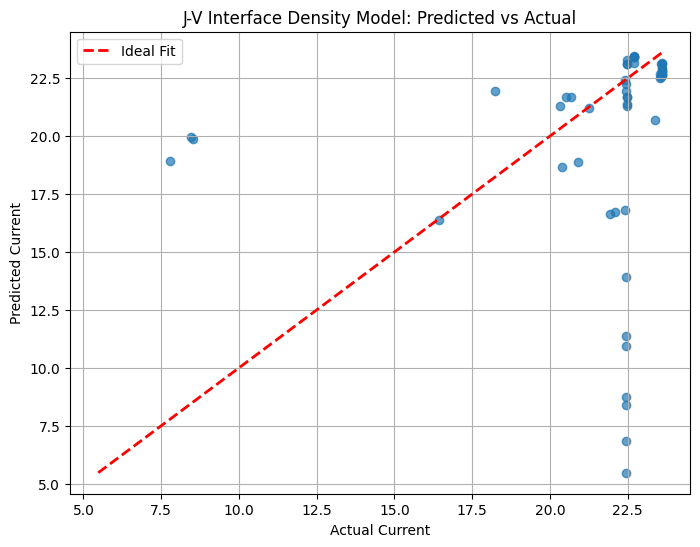

In [12]:
# =========================================================
# J-V MACHINE LEARNING MODEL (INTERFACE DENSITY)
# =========================================================

# Features and target
X_jv = jv_long[['Voltage', 'Interface_Density']]
y_jv = jv_long['Current']

# Train-test split
X_train_jv, X_test_jv, y_train_jv, y_test_jv = train_test_split(
    X_jv, y_jv,
    test_size=0.2,
    random_state=42
)

# Model
jv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
jv_model.fit(X_train_jv, y_train_jv)

# Predict
y_pred_jv = jv_model.predict(X_test_jv)

# Metrics
print("J-V Interface Density Model Performance")
print("R² Score:", r2_score(y_test_jv, y_pred_jv))
print("MAE:", mean_absolute_error(y_test_jv, y_pred_jv))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_jv, y_pred_jv, alpha=0.7)

# Ideal reference line
min_val = min(y_test_jv.min(), y_pred_jv.min())
max_val = max(y_test_jv.max(), y_pred_jv.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")
plt.title("J-V Interface Density Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

QE Interface Density Model Performance
R² Score: 0.9991464418781182
MAE: 0.4749223129062306


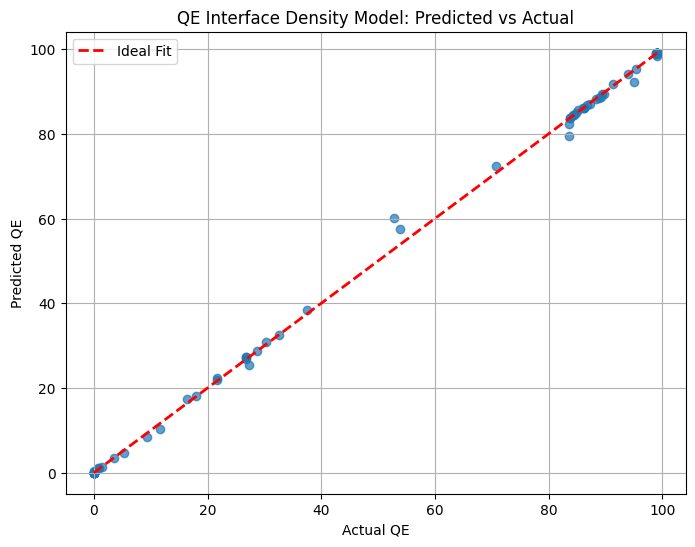

In [13]:
# =========================================================
# QE MACHINE LEARNING MODEL (INTERFACE DENSITY)
# =========================================================

# Features and target
X_qe = qe_long[['Wavelength', 'Interface_Density']]
y_qe = qe_long['QE']

# Train-test split
X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(
    X_qe, y_qe,
    test_size=0.2,
    random_state=42
)

# Model
qe_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
qe_model.fit(X_train_qe, y_train_qe)

# Predict
y_pred_qe = qe_model.predict(X_test_qe)

# Metrics
print("QE Interface Density Model Performance")
print("R² Score:", r2_score(y_test_qe, y_pred_qe))
print("MAE:", mean_absolute_error(y_test_qe, y_pred_qe))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_qe, y_pred_qe, alpha=0.7)

# Ideal reference line
min_val = min(y_test_qe.min(), y_pred_qe.min())
max_val = max(y_test_qe.max(), y_pred_qe.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")
plt.title("QE Interface Density Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

Responsivity Interface Density Model Performance
R² Score: 0.9986883900702809
MAE: 0.0038935111606737466


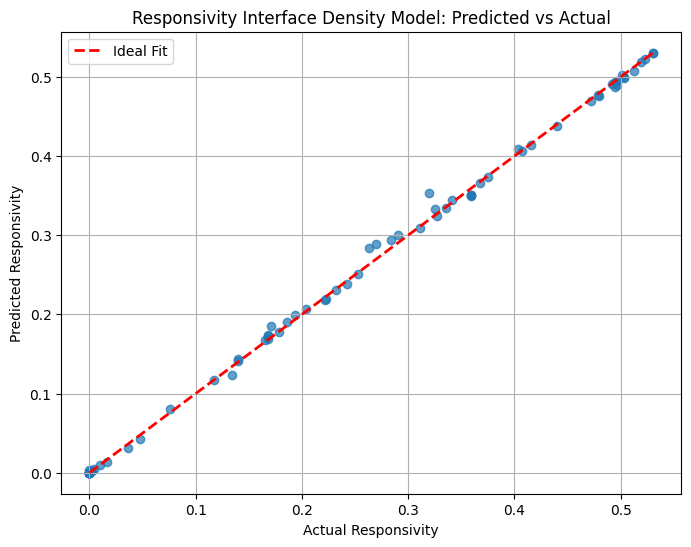

In [ ]:
# =========================================================
# RESPONSIVITY MACHINE LEARNING MODEL (INTERFACE DENSITY)
# =========================================================

# Features and target
X_r = r_long[['Wavelength', 'Interface_Density']]
y_r = r_long['Responsivity']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.2,
    random_state=42
)

# Model
r_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
r_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = r_model.predict(X_test_r)

# Metrics
print("Responsivity Interface Density Model Performance")
print("R² Score:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.7)

# Ideal reference line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")
plt.title("Responsivity Interface Density Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================================================
# PREDICT CURRENT (INTERFACE DENSITY)
# =========================================================

def predict_current(voltage, interface_density):

    prediction = jv_model.predict([[voltage, interface_density]])[0]

    print(f"Predicted Current Density at {voltage} V and 10^{int(interface_density)} Interface Density: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

voltage = float(input("Enter Voltage (V): "))
interface_density = float(input("Enter Interface Density Exponent (Example: 10 for 10^10): "))

predict_current(voltage, interface_density)

In [ ]:
# =========================================================
# PREDICT QE (INTERFACE DENSITY)
# =========================================================

def predict_qe(wavelength, interface_density):

    prediction = qe_model.predict([[wavelength, interface_density]])[0]

    print(f"Predicted QE at {wavelength} nm and 10^{int(interface_density)} Interface Density: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
interface_density = float(input("Enter Interface Density Exponent (Example: 10 for 10^10): "))

predict_qe(wavelength, interface_density)

In [ ]:
# =========================================================
# PREDICT RESPONSIVITY (INTERFACE DENSITY)
# =========================================================

def predict_responsivity(wavelength, interface_density):

    prediction = r_model.predict([[wavelength, interface_density]])[0]

    print(f"Predicted Responsivity at {wavelength} nm and 10^{int(interface_density)} Interface Density: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
interface_density = float(input("Enter Interface Density Exponent (Example: 10 for 10^10): "))

predict_responsivity(wavelength, interface_density)

In [15]:
# =========================================================
# PREDICT FULL J-V CURVE (INTERFACE DENSITY)
# =========================================================

def predict_jv_curve(interface_density):

    voltage_range = np.linspace(
        jv_long['Voltage'].min(),
        jv_long['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Interface_Density': interface_density
    })

    predicted_current = jv_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_current,
        label=f'Predicted Interface Density = 10^{int(interface_density)}'
    )

    plt.title("Predicted J-V Curve")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

interface_density = float(input("Enter Interface Density Exponent (Example: 10 for 10^10): "))

predict_jv_curve(interface_density)

In [ ]:
# =========================================================
# PREDICT FULL QE CURVE (INTERFACE DENSITY)
# =========================================================

def predict_qe_curve(interface_density):

    wavelength_range = np.linspace(
        qe_long['Wavelength'].min(),
        qe_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Interface_Density': interface_density
    })

    predicted_qe = qe_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_qe,
        label=f'Predicted Interface Density = 10^{int(interface_density)}'
    )

    plt.title("Predicted QE Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

interface_density = float(input("Enter Interface Density Exponent (Example: 10 for 10^10): "))

predict_qe_curve(interface_density)

In [ ]:
# =========================================================
# PREDICT FULL RESPONSIVITY CURVE (INTERFACE DENSITY)
# =========================================================

def predict_r_curve(interface_density):

    wavelength_range = np.linspace(
        r_long['Wavelength'].min(),
        r_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Interface_Density': interface_density
    })

    predicted_r = r_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_r,
        label=f'Predicted Interface Density = 10^{int(interface_density)}'
    )

    plt.title("Predicted Responsivity Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

interface_density = float(input("Enter Interface Density Exponent (Example: 10 for 10^10): "))

predict_r_curve(interface_density)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED J-V CURVE (INTERFACE DENSITY)
# =========================================================

def compare_jv_actual_vs_predicted(interface_density):

    # Actual SCAPS data
    actual_data = jv_long[jv_long['Interface_Density'] == interface_density]

    if actual_data.empty:
        print("Interface Density not found in dataset.")
        return

    # Predicted curve
    voltage_range = np.linspace(
        actual_data['Voltage'].min(),
        actual_data['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Interface_Density': interface_density
    })

    predicted_current = jv_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Voltage'],
        actual_data['Current'],
        label="Actual SCAPS"
    )

    plt.plot(
        voltage_range,
        predicted_current,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted J-V Curve (10^{int(interface_density)})")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

interface_density = float(input("Enter Existing Interface Density Exponent (Example: 10 for 10^10): "))

compare_jv_actual_vs_predicted(interface_density)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED QE CURVE (INTERFACE DENSITY)
# =========================================================

def compare_qe_actual_vs_predicted(interface_density):

    # Actual SCAPS data
    actual_data = qe_long[qe_long['Interface_Density'] == interface_density]

    if actual_data.empty:
        print("Interface Density not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Interface_Density': interface_density
    })

    predicted_qe = qe_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['QE'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_qe,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted QE Curve (10^{int(interface_density)})")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

interface_density = float(input("Enter Existing Interface Density Exponent (Example: 10 for 10^10): "))

compare_qe_actual_vs_predicted(interface_density)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED RESPONSIVITY CURVE (INTERFACE DENSITY)
# =========================================================

def compare_r_actual_vs_predicted(interface_density):

    # Actual SCAPS data
    actual_data = r_long[r_long['Interface_Density'] == interface_density]

    if actual_data.empty:
        print("Interface Density not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Interface_Density': interface_density
    })

    predicted_r = r_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['Responsivity'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_r,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted Responsivity Curve (10^{int(interface_density)})")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

interface_density = float(input("Enter Existing Interface Density Exponent (Example: 10 for 10^10): "))

compare_r_actual_vs_predicted(interface_density)

In [ ]:
# =========================================================
# INTERFACE DENSITY THEORY + SYSTEM WORKING
# =========================================================

print("""
============================================================
INTERFACE DENSITY VARIATION THEORY IN PEROVSKITE SOLAR CELLS
============================================================

In this project, Interface Density refers to the defect density 
present at the interface between adjacent layers of the solar cell, 
typically between the absorber layer and transport layers.

These interface defects act as recombination centers where charge 
carriers may be trapped or lost before collection.

Thus, interface density is an important electronic quality parameter 
because it directly affects charge extraction efficiency.

------------------------------------------------------------
WHY INTERFACE DENSITY IS IMPORTANT
------------------------------------------------------------

Interface Density influences:
• Charge recombination
• Carrier trapping
• Interface quality
• Current density
• Voltage behavior
• Spectral response

At lower interface density:
• Fewer trap states
• Better carrier extraction
• Reduced recombination

At higher interface density:
• More trap-assisted recombination
• Increased carrier loss
• Reduced device efficiency

Therefore, studying interface density helps evaluate how defect 
concentration at interfaces affects solar-cell performance.

------------------------------------------------------------
ROLE OF SCAPS DATASET
------------------------------------------------------------

The Excel dataset contains SCAPS-generated simulation data for 
multiple interface density values represented as:
10^10, 10^12, 10^14, 10^16, 10^18, 10^20

For each interface density, SCAPS provides:

1. J–V Data:
Voltage vs Current Density

2. QE Data:
Wavelength vs Quantum Efficiency

3. Responsivity Data:
Wavelength vs Responsivity

Each density therefore represents a different defect-condition 
simulation of the solar cell.

------------------------------------------------------------
WHAT THIS ML SYSTEM DOES
------------------------------------------------------------

Instead of manually analyzing every interface density separately, 
Machine Learning learns defect-response behavior from SCAPS data.

Three Random Forest models are trained:

J–V Model:
(Voltage + Interface Density) → Current

QE Model:
(Wavelength + Interface Density) → QE

Responsivity Model:
(Wavelength + Interface Density) → Responsivity

For ML simplicity, densities are represented using exponent form:
10^10 → 10
10^12 → 12

This allows prediction of:
• Current at selected voltage and density
• QE at selected wavelength and density
• Responsivity at selected wavelength and density
• Full predicted curves for user-selected density

------------------------------------------------------------
MODEL VALIDATION
------------------------------------------------------------

To ensure reliability:
• R² Score evaluates predictive accuracy
• MAE measures average error
• Predicted vs Actual plots verify consistency

This confirms whether ML successfully captures interface-defect trends.

------------------------------------------------------------
ACTUAL vs PREDICTED COMPARISON
------------------------------------------------------------

For known interface density values:
• Actual SCAPS curves are plotted
• Predicted ML curves are plotted

This helps evaluate:
• Learning quality
• Defect-pattern understanding
• Predictive consistency

------------------------------------------------------------
SYSTEM SIGNIFICANCE
------------------------------------------------------------

This framework combines:
SCAPS Simulation + Interface Defect Analysis + Machine Learning

Thus, it serves as:
• Interface quality analysis tool
• Predictive modeling framework
• Visualization system

Rather than replacing SCAPS, this system extends defect analysis 
by enabling:
• Faster predictions
• Easier defect-condition exploration
• Reusable analysis framework

============================================================
FINAL SUMMARY
============================================================

Interface Density represents defect concentration at layer interfaces.
It strongly affects recombination and charge extraction.
SCAPS provides interface-density-based simulation data.
Machine Learning learns defect-response behavior.
The final system predicts and visualizes interface density effects.

In short:
This project creates a reusable interface-defect simulation and 
prediction framework for perovskite solar-cell analysis.
============================================================
""")